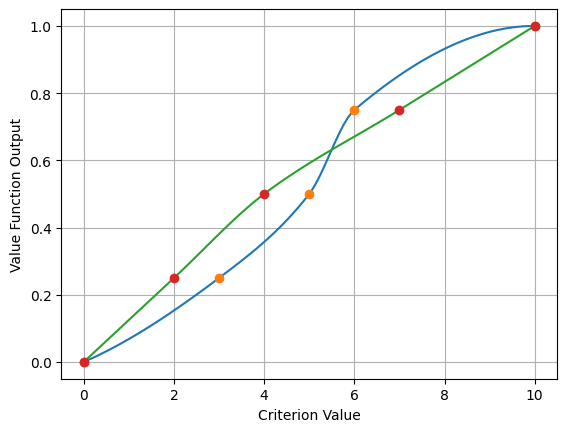

In [16]:

# Results of value function elicitation
C1_vf_a_points = [0, 3, 5, 6, 10]
C1_vf_b_points = [0, 2, 4, 7, 10]
C2_vf_a_points = [0, 4, 6, 8, 10]
C2_vf_b_points = [0, 3, 5, 7, 10]
C3_vf_a_points = [0, 2, 7, 9, 10]
C3_vf_b_points = [0, 1, 6, 8, 10]

elicitation_values = [0, 0.25, 0.5, 0.75, 1]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator


def value_function(*points):
    x = np.linspace(0, 10, 100)
    value_functions = []
    for point in points:
        vf = PchipInterpolator(point, elicitation_values)
        value_functions.append(vf)
        plt.plot(x, vf(x))
        plt.plot(point, elicitation_values, "o")

    plt.xlabel("Criterion Value")
    plt.ylabel("Value Function Output")
    plt.grid()
    plt.show()
    return value_functions

vf_C1 = value_function(C1_vf_a_points, C1_vf_b_points)

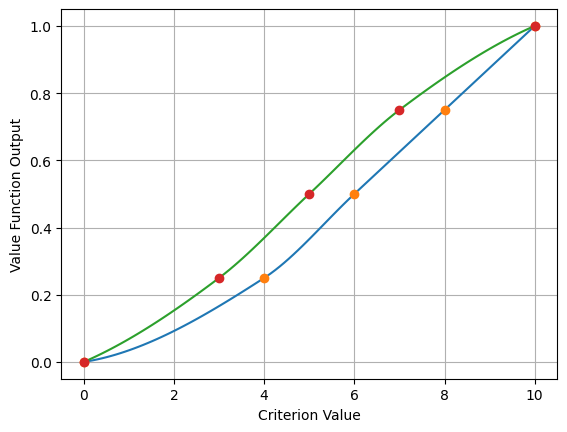

In [17]:
vf_C2 = value_function(C2_vf_a_points, C2_vf_b_points)


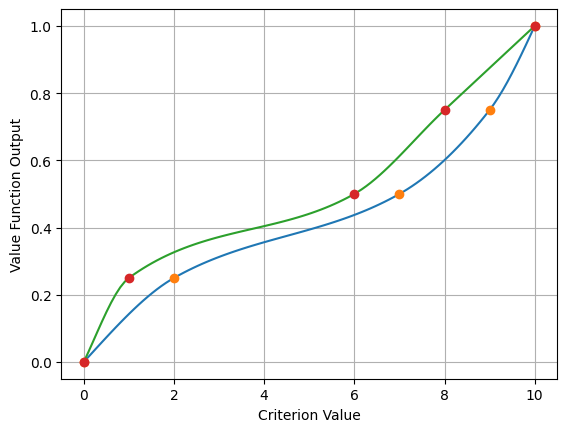

In [18]:
vf_C3 = value_function(C3_vf_a_points, C3_vf_b_points)


In [19]:
# For each x, a value function vf_C* returns an uniform distribution between the minimum and maximum value functions.

def vf_call(x, v_fs):
    v_min = min(vf(x) for vf in v_fs)
    v_max = max(vf(x) for vf in v_fs)
    return (float(v_min), float(v_max))

print(vf_call(5, vf_C1))

(0.5, 0.5913413413413413)


In [20]:
# Let's assume all criteria are between 0 and 10
criteria = ["C1", "C2", "C3"]
weights = [[0.5, 0.55], [0.3, 0.33], [0.2, 0.22]]

alternative_A = [[8, 9], [7, 7.7], [8, 8.8]]  # Criterion values for alternative A
alternative_B = [[6, 6.6], [6, 6.6], [7, 7.7]]  # Criterion values for alternative B
alternative_C = [[2, 2.2], [3, 3.3], [9, 9.9]]  # Criterion values for alternative C

In [21]:
# Compute values
vf_list = [vf_C1, vf_C2, vf_C3]
alternatives = [alternative_A, alternative_B, alternative_C]
results = []
for i in range(len(alternatives)):
    values = []
    for j in range(len(vf_list)):
        min_val_low, max_val_low = vf_call(alternatives[i][j][0], vf_list[j])
        min_val_high, max_val_high = vf_call(alternatives[i][j][1], vf_list[j])
        value_range = [min(min_val_low, min_val_high), max(max_val_low, max_val_high)]
        values.append(value_range)
    results.append(values)
    print(f"Alternative {chr(65+i)}: Values = {values}")

Alternative A: Values = [[0.8333333333333334, 0.9822443181818182], [0.625, 0.8188773023023023], [0.600752508361204, 0.8500000000000001]]
Alternative B: Values = [[0.6706706706706705, 0.8144488636363636], [0.5, 0.7060540540540541], [0.5, 0.7106290760869566]]
Alternative C: Values = [[0.1531031031031031, 0.2754256756756757], [0.1661658653846154, 0.2823741554054054], [0.75, 0.9875]]


In [22]:

cumulative_results = np.zeros(len(alternatives))
average_values = np.zeros(len(alternatives))
std_values = np.zeros(len(alternatives))

num_simulations = 10000
# Monte Carlo Simulation
# Initialize arrays to store results for each simulation
simulation_results = np.zeros((len(alternatives), num_simulations))

for sim in range(num_simulations):
    for i in range(len(alternatives)):
        values = results[i]  # Value ranges for alternative i
        weighted_value = 0
        for j in range(len(values)):
            weight_range = weights[j]
            value_range = values[j]
            sampled_value = np.random.uniform(value_range[0], value_range[1])
            sampled_weight = np.random.uniform(weight_range[0], weight_range[1])
            weighted_value += sampled_value * sampled_weight
        simulation_results[i, sim] = weighted_value

# Calculate average and standard deviation
average_values = np.mean(simulation_results, axis=1)
std_values = np.std(simulation_results, axis=1, ddof=1)  # ddof=1 for sample standard deviation

for i in range(len(alternatives)):
    print(f"Alternative {chr(65+i)}: Average Weighted Value = {average_values[i]}, Standard Deviation = {std_values[i]}")


Alternative A: Average Weighted Value = 0.8565277701345738, Standard Deviation = 0.0355863983872883
Alternative B: Average Weighted Value = 0.7072159472873555, Standard Deviation = 0.03404083380249634
Alternative C: Average Weighted Value = 0.36552375276263144, Standard Deviation = 0.026796960691405348
